# Annotation of artefacts

## Introduction

The aim of this notebook is to demonstrate how artefacts can be identified and annotated in the DAD MEG recordings after MaxFilter. This follows the structure of the FLUX artefact annotation notebook, but the eye-tracking part is adapted to the local DAD data.

The important point is that sections of data are annotated here, not deleted. These annotations are saved in the FIF file and can later be used during epoching to reject affected trials or time periods. This keeps the artefact evidence visible and reversible.

The FIF files contain eye-tracker analog channels as `MISC001`-`MISC006`:

- `MISC001`, `MISC002`, `MISC003`: left-eye analog signals;
- `MISC004`, `MISC005`, `MISC006`: right-eye analog signals.

This notebook uses these MISC eye-tracker channels to annotate blinks and eye movements. The channel names are stored in `config.toml`.

## Preparation

Import the relevant modules.

In [21]:
from pathlib import Path
try:
    import tomllib
except ModuleNotFoundError:  # for Python < 3.11
    import tomli as tomllib
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.preprocessing import annotate_muscle_zscore

### File overview

The notebook relies on the MaxFiltered derivatives created by `01_maxfilter.ipynb`. With the default config, the inputs are:

~~~text
<ROOT>/derivatives/mne-preprocessing/sub-06/ses-20260526/meg/sub-06_ses-20260526_task-movdot_run-01_desc-maxfilter_meg.fif
<ROOT>/derivatives/mne-preprocessing/sub-06/ses-20260526/meg/sub-06_ses-20260526_task-movdot_run-02_desc-maxfilter_meg.fif
<ROOT>/derivatives/mne-preprocessing/sub-06/ses-20260526/meg/sub-06_ses-20260526_task-movdot_run-03_desc-maxfilter_meg.fif
~~~

and the annotated outputs are:

~~~text
<ROOT>/derivatives/mne-preprocessing/sub-06/ses-20260526/meg/sub-06_ses-20260526_task-movdot_run-01_desc-annotated_meg.fif
<ROOT>/derivatives/mne-preprocessing/sub-06/ses-20260526/meg/sub-06_ses-20260526_task-movdot_run-01_desc-annotations.csv
...
~~~

To process participant 07, change `subject`, `session`, and `runs` in `config.toml`.

Read `config.toml`, select the configured BIDS subject/session/runs, and build the MaxFiltered inputs and annotated outputs. The notebook uses the same paths as the companion script.

In [22]:
# -----------------------------------------------------------------------------
# Load shared configuration
# -----------------------------------------------------------------------------
# All user-facing settings live in config.toml. If ``root`` is relative, it is
# interpreted relative to the config file so the whole folder can be moved.

script_dir = Path('__file__').resolve().parent
config_file = Path('config.toml')
if not config_file.exists():
    for parent in Path.cwd().resolve().parents:
        candidate = parent / 'config.toml'
        if candidate.exists():
            config_file = candidate
            break
if not config_file.exists():
    raise FileNotFoundError('Could not find config.toml. Start Jupyter from the pipeline root or edit config_file.')

with config_file.open("rb") as fid:
    config = tomllib.load(fid)

root = Path(config["paths"]["root"])
if not root.is_absolute():
    root = (config_file.parent / root).resolve()

subject = str(config["dataset"]["subject"]).zfill(2)
session = str(config["dataset"]["session"])
task = str(config["dataset"]["task"])
run_labels = [f"{int(run):02d}" for run in config["dataset"]["runs"]]

bids_subject = f"sub-{subject}"
bids_session = f"ses-{session}"
bids_prefix = f"{bids_subject}_{bids_session}_task-{task}"

deriv_root = root / config["paths"]["derivatives"]
maxfilter_dir = deriv_root / bids_subject / bids_session / "meg"
annotation_dir = deriv_root / bids_subject / bids_session / "meg"
manual_eye_annotation_dir = annotation_dir / "manual_eye"
report_dir = deriv_root / bids_subject / bids_session / "reports"
annotation_dir.mkdir(parents=True, exist_ok=True)
manual_eye_annotation_dir.mkdir(parents=True, exist_ok=True)
report_dir.mkdir(parents=True, exist_ok=True)

report_file = report_dir / "02_artefact_annotation.html"
report = mne.Report(title=f"02 Artefact annotation - {bids_subject} {bids_session}")

maxfilter_files = [
    maxfilter_dir / f"{bids_prefix}_run-{run}_desc-maxfilter_meg.fif"
    for run in run_labels
]
missing_maxfilter_files = [path for path in maxfilter_files if not path.is_file()]
if missing_maxfilter_files:
    missing = "\n  ".join(str(path) for path in missing_maxfilter_files)
    raise FileNotFoundError(
        "Missing configured MaxFiltered files. Run 01_maxfilter.py first.\n  "
        f"{missing}"
    )

annotation_files = {
    max_file: annotation_dir / max_file.name.replace(
        "_desc-maxfilter_meg.fif", "_desc-annotated_meg.fif"
    )
    for max_file in maxfilter_files
}
annotation_csv_files = {
    max_file: annotation_dir / max_file.name.replace(
        "_desc-maxfilter_meg.fif", "_desc-annotations.csv"
    )
    for max_file in maxfilter_files
}
manual_eye_annotation_files = {
    max_file: manual_eye_annotation_dir / max_file.name.replace(
        "_desc-maxfilter_meg.fif", "_desc-manualeye-annot.fif"
    )
    for max_file in maxfilter_files
}

print("Config file:")
print("  ", config_file)
print("Pipeline root:")
print("  ", root)
print("Subject/session/task/runs:")
print("  ", bids_subject, bids_session, task, run_labels)

print("Input MaxFiltered files:")
for path in maxfilter_files:
    print("  ", path)

print("\nManual eye-annotation files:")
for path in manual_eye_annotation_files.values():
    print("  ", path)

print("\nOutput annotation files:")
for path in annotation_files.values():
    print("  ", path)

print("\nReport file:")
print("  ", report_file)

Embedding : jquery-3.6.0.min.js
Embedding : bootstrap.bundle.min.js
Embedding : bootstrap.min.css
Embedding : bootstrap-table/bootstrap-table.min.js
Embedding : bootstrap-table/bootstrap-table.min.css
Embedding : bootstrap-table/bootstrap-table-copy-rows.min.js
Embedding : bootstrap-table/bootstrap-table-export.min.js
Embedding : bootstrap-table/tableExport.min.js
Embedding : bootstrap-icons/bootstrap-icons.mne.min.css
Embedding : highlightjs/highlight.min.js
Embedding : highlightjs/atom-one-dark-reasonable.min.css
Config file:
   /Users/goal0312/Desktop/thesis/data/config.toml
Pipeline root:
   /Users/goal0312/Desktop/thesis/data
Subject/session/task/runs:
   sub-01 ses-01 IceSkating ['01']
Input MaxFiltered files:
   /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_desc-maxfilter_meg.fif

Manual eye-annotation files:
   /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/manual_eye

In [3]:
config

{'paths': {'root': '.', 'derivatives': 'derivatives/mne-preprocessing'},
 'dataset': {'subject': '01',
  'session': '01',
  'task': 'IceSkating',
  'runs': [1, 2, 3, 4, 5, 6]},
 'eye_tracker': {'left': ['MISC001', 'MISC002', 'MISC003'],
  'right': ['MISC004', 'MISC005', 'MISC006']},
 'annotation': {'manual_annotation_run_index': 0,
  'skip_manual_eye_ann': False,
  'threshold_muscle': 10},
 'ica': {'n_components': 30,
  'random_state': 97,
  'resample_sfreq': 200,
  'l_freq': 1.0,
  'h_freq': 40.0,
  'candidate_components': [0, 1],
  'exclude_components': []}}

In [ ]:
mne.compute_rank(manual_raw, 

<Raw | sub-01_ses-01_task-IceSkating_run-01_desc-maxfilter_meg.fif, 326 x 732000 (732.0 s), ~1.78 GiB, data loaded>

In [23]:
manual_annotation_run_index = int(config['annotation']['manual_annotation_run_index'])
first_file = maxfilter_files[manual_annotation_run_index]
raw1 = mne.io.read_raw_fif(first_file, preload=True, verbose=True)
print(raw1)

Opening raw data file /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_desc-maxfilter_meg.fif...
    Range : 20000 ... 751999 =     20.000 ...   751.999 secs
Ready.
Reading 0 ... 731999  =      0.000 ...   731.999 secs...
<Raw | sub-01_ses-01_task-IceSkating_run-01_desc-maxfilter_meg.fif, 326 x 732000 (732.0 s), ~1.78 GiB, data loaded>


## Manually annotate blinks and eye movements from eye-tracker analog channels

The DAD FIF files store analog eye-tracker signals in MISC channels. By default, `MISC001`-`MISC003` contain the left-eye analog signals and `MISC004`-`MISC006` contain the right-eye analog signals. The exact channel list is read from `config.toml`.

In this notebook we do not automatically threshold those channels. Instead, we inspect each run in the MNE raw browser and manually mark time intervals containing blinks or eye movements. This keeps the example simple and avoids pretending that one robust-z threshold is a universal eye-tracker solution.

The manual labels to use are:

- `BAD_blink` for blinks or pupil-loss/dropout periods;
- `BAD_eye_movement` for clear eye movements, gaze shifts, or tracking artefacts that should reject overlapping trials.

Each run is reviewed separately. Change `annotation.manual_annotation_run_index` in `config.toml`, run the interactive browser, add or edit annotations, close the browser, and then save the manual eye annotations for that run. Repeat this for each configured run before running the final batch cell.


In [5]:
# -----------------------------------------------------------------------------
# Eye-tracker channel mapping and manual-review settings
# -----------------------------------------------------------------------------

# eye tracker names
left_eye = config['eye_tracker']['left']
right_eye = config['eye_tracker']['right']

# instead of misc reads x,y,pupil for each eye
left_eye_channels = {
    'x': left_eye[0],
    'y': left_eye[1],
    'pupil_or_validity': left_eye[2],
}
right_eye_channels = {
    'x': right_eye[0],
    'y': right_eye[1],
    'pupil_or_validity': right_eye[2],
}

# collate 6 channel names into a flat list
eye_tracker_channels = [
    left_eye_channels['x'],
    left_eye_channels['y'],
    left_eye_channels['pupil_or_validity'],
    right_eye_channels['x'],
    right_eye_channels['y'],
    right_eye_channels['pupil_or_validity'],
]

missing_eye_channels = [ch for ch in eye_tracker_channels if ch not in raw1.ch_names]
if missing_eye_channels:
    raise RuntimeError(f'Missing expected eye-tracker MISC channels: {missing_eye_channels}')

# Set this to True only if you intentionally want the batch step to continue
# when a run has not been manually reviewed for eye artefacts.
skip_manual_eye_ann = bool(config['annotation']['skip_manual_eye_ann'])

## we run this whole script 6 times for 6 runs and change manual_annotation_run_index from 0 to 5
if manual_annotation_run_index >= len(maxfilter_files):
    raise IndexError('annotation.manual_annotation_run_index is outside the configured run list.')
manual_file = maxfilter_files[manual_annotation_run_index]
manual_raw = mne.io.read_raw_fif(manual_file, preload=True, verbose=True)

# Frontal sensors are useful context because eye-related artefacts are strongest
# at the front of the helmet. These Neuromag sensor groups are intentionally
# broad enough to show frontal MEG activity without plotting the whole recording.
frontal_meg_prefixes = (
    'MEG011', 'MEG012', 'MEG013', 'MEG014',
    'MEG021', 'MEG022', 'MEG023', 'MEG024',
    'MEG031', 'MEG032', 'MEG033', 'MEG034',
    'MEG041', 'MEG042', 'MEG043', 'MEG044',
    'MEG051', 'MEG052', 'MEG053', 'MEG054',
) # 20 prefixes - sensors
frontal_meg_channels = [
    ch for ch in manual_raw.ch_names
    if ch.startswith(frontal_meg_prefixes)
] # 60 channels from both gradio + magno

# if there is no frontal channels with the naming convention, take the first 30 channels
if not frontal_meg_channels:
    frontal_meg_channels = [
        manual_raw.ch_names[pick]
        for pick in mne.pick_types(manual_raw.info, meg=True, eeg=False, stim=False, misc=False)
    ][:30]

manual_plot_channels = frontal_meg_channels + eye_tracker_channels
manual_eye_annotation_prefixes = ('BAD_blink', 'BAD_eye_movement')

print('Selected run:', manual_annotation_run_index, manual_file.name)
print('Manual eye annotations will be saved to:')
print('  ', manual_eye_annotation_files[manual_file])
print('Channels shown in the interactive browser:', len(manual_plot_channels))
print('Eye-tracker channels:', eye_tracker_channels)

Opening raw data file /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_desc-maxfilter_meg.fif...
    Range : 20000 ... 751999 =     20.000 ...   751.999 secs
Ready.
Reading 0 ... 731999  =      0.000 ...   731.999 secs...
Selected run: 0 sub-01_ses-01_task-IceSkating_run-01_desc-maxfilter_meg.fif
Manual eye annotations will be saved to:
   /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/manual_eye/sub-01_ses-01_task-IceSkating_run-01_desc-manualeye-annot.fif
Channels shown in the interactive browser: 66
Eye-tracker channels: ['MISC001', 'MISC002', 'MISC003', 'MISC004', 'MISC005', 'MISC006']


Open the interactive browser and annotate blinks and eye movements.

The browser shows frontal MEG sensors together with the six eye-tracker MISC channels. Use the MNE annotation tools in the browser to mark bad intervals. The labels must start with `BAD_blink` or `BAD_eye_movement` so the later cells can identify them as manually reviewed eye artefacts.

The command uses the Qt backend because manual annotation is easier in an external interactive MNE window than in an inline notebook figure. Close the browser window when you are done; the annotations you added remain stored in `manual_raw.annotations`.


In [7]:
frontal_meg_channels

['MEG0111',
 'MEG0112',
 'MEG0113',
 'MEG0121',
 'MEG0122',
 'MEG0123',
 'MEG0131',
 'MEG0132',
 'MEG0133',
 'MEG0141',
 'MEG0142',
 'MEG0143',
 'MEG0211',
 'MEG0212',
 'MEG0213',
 'MEG0221',
 'MEG0222',
 'MEG0223',
 'MEG0231',
 'MEG0232',
 'MEG0233',
 'MEG0241',
 'MEG0242',
 'MEG0243',
 'MEG0311',
 'MEG0312',
 'MEG0313',
 'MEG0321',
 'MEG0322',
 'MEG0323',
 'MEG0331',
 'MEG0332',
 'MEG0333',
 'MEG0341',
 'MEG0342',
 'MEG0343',
 'MEG0411',
 'MEG0412',
 'MEG0413',
 'MEG0421',
 'MEG0422',
 'MEG0423',
 'MEG0431',
 'MEG0432',
 'MEG0433',
 'MEG0441',
 'MEG0442',
 'MEG0443',
 'MEG0511',
 'MEG0512',
 'MEG0513',
 'MEG0521',
 'MEG0522',
 'MEG0523',
 'MEG0531',
 'MEG0532',
 'MEG0533',
 'MEG0541',
 'MEG0542',
 'MEG0543']

In [27]:
manual_plot_scalings

{'mag': 'auto', 'grad': 'auto', 'misc': 1.0}

In [6]:
%matplotlib qt

manual_plot_scalings = dict(
    mag='auto',
    grad='auto',
    misc=1.0,
)

manual_raw.plot(
    picks=manual_plot_channels,
    n_channels=len(manual_plot_channels),
    duration=20,
    scalings=manual_plot_scalings,
    remove_dc=True,
    block=True,
)


Using qt as 2D backend.


qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=467.711,212.617 gbl=467.711,212.617 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-467.711,-212.617 last=-467.711,-212.617 Δ 467.711,212.617) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=571.859,640.453 gbl=571.859,640.453 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-571.859,-640.453 last=-571.859,-640.453 Δ 571.859,640.453) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=577.795,579.046 gbl=577.795,579.046 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-577.795,-579.046 last=-577.795,-579.046 Δ 577.795,579.046) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=386.854,117.275 gbl=386.854,117.275 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-386.854,-117.275 last=-386.854,-117.275 Δ 386.854,117.275) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=0 ts=0 pos=0,0 scn=275.583,914.252 gbl=275.583,914.252 Released ellipse=(1x

Channels marked as bad:
none


<mne_qt_browser._pg_figure.MNEQtBrowser(0x0) at 0x184a83f80>

2026-07-20 15:12:08.881 python[4968:3772505] _TIPropertyValueIsValid called with 4 on nil context!
2026-07-20 15:12:08.882 python[4968:3772505] imkxpc_getApplicationProperty:reply: called with incorrect property value 4, bailing.
2026-07-20 15:12:08.882 python[4968:3772505] Text input context does not respond to _valueForTIProperty:


Save the manual eye annotations for the selected run.

This cell writes only annotations whose description starts with `BAD_blink` or `BAD_eye_movement`. Existing acquisition annotations are left in the raw file and are not duplicated into the manual eye-annotation file. Saving an empty annotation file is allowed; it means the run was inspected and no blink or eye-movement intervals were marked.


In [ ]:
MISC1=RX (Right eye, X axis)  

MISC2=RY   (Right eye, Y axis)  

MISC3=RP   (Right eye, Pupil size)  

MISC4=LX   (Left eye, X axis)  

MISC5=LY   (Left eye, Y axis)  

MISC6=LP (Left eye, Pupil size)  

In [36]:
index,description = 0, manual_raw.annotations.description[0]
index,description

(0, np.str_('BAD_blink'))

In [7]:
keep = [
        index
        for index, description in enumerate(manual_raw.annotations.description) # (n_bad_manual_annotations,) 
        if description.startswith(manual_eye_annotation_prefixes)
    ]
keep

[]

In [7]:
def extract_manual_eye_annotations(raw):
    """Return only manually marked blink and eye-movement annotations."""
    keep = [
        index
        for index, description in enumerate(raw.annotations.description) # (n_bad_manual_annotations,) 
        if description.startswith(manual_eye_annotation_prefixes)
    ] # len 184
    if not keep: # no manual annotations
        return mne.Annotations([], [], [], orig_time=raw.info['meas_date'])
        # mne.Annotations(onset, duration, description, orig_time) here onset,duration,description = [],[],[] 
    return mne.Annotations(
        onset=raw.annotations.onset[keep],
        duration=raw.annotations.duration[keep],
        description=raw.annotations.description[keep],
        orig_time=raw.annotations.orig_time,
    )


def load_manual_eye_annotations(maxfilter_file, raw, *, allow_missing=False):
    """Load manual blink/eye-movement annotations for one MaxFiltered run."""
    manual_eye_file = manual_eye_annotation_files[maxfilter_file]
    if manual_eye_file.exists():
        annotations = mne.read_annotations(manual_eye_file)
        print(f'Loaded {len(annotations)} manual eye annotations from {manual_eye_file}')
        return annotations

    if allow_missing:
        print(
            'WARNING: no manual eye annotations found for '
            f'{maxfilter_file.name}; continuing without blink/eye-movement annotations.'
        )
        return mne.Annotations([], [], [], orig_time=raw.info['meas_date'])

    raise FileNotFoundError(
        'Manual eye annotations are missing for '
        f'{maxfilter_file.name}. Annotate this run first, or set '
        'skip_manual_eye_ann = True to continue without them.'
    )


manual_eye_annotations = extract_manual_eye_annotations(manual_raw)
manual_eye_annotation_file = manual_eye_annotation_files[manual_file]
manual_eye_annotations.save(manual_eye_annotation_file, overwrite=True)

print(f'Saved {len(manual_eye_annotations)} manual eye annotations to:')
print('  ', manual_eye_annotation_file)
print('Descriptions:', sorted(set(manual_eye_annotations.description)))


Overwriting existing file.
Overwriting existing file.
Saved 4 manual eye annotations to:
   /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/manual_eye/sub-01_ses-01_task-IceSkating_run-01_desc-manualeye-annot.fif
Descriptions: [np.str_('BAD_blink')]


## Finding muscle artefacts

Muscle artefacts are identified from magnetometer data filtered in the 110-140 Hz range. The filtered data are z-scored. If they exceed `threshold_muscle`, the corresponding segment is annotated as muscle artefact.

This follows the FLUX default threshold of 10. As with eye-tracker thresholds, this value should be inspected for each dataset.

In [51]:
manual_raw.annotations

<Annotations | 184 segments: BAD_blink (56), BAD_eye_movement (128)>

In [8]:
threshold_muscle = config['annotation']['threshold_muscle']

## how many standard deviations above the mean is the high-frequency power
## => scores_muscle; one z score valye per time sample
## min_length_good: merge shorter than 0.2s gaps between consecutive bad stretches 
## into the surrounding bad segments.

## so annotations_muscle is an mne.Annotations object 
## scores_muscles z-score time series for plotting
annotations_muscle, scores_muscle = annotate_muscle_zscore(
    raw1,
    ch_type='mag',
    threshold=threshold_muscle,
    min_length_good=0.2,
    filter_freq=[110, 140],
)
print('muscle annotations:', len(annotations_muscle))

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1.1e+02 - 1.4e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 110.00
- Lower transition bandwidth: 27.50 Hz (-6 dB cutoff frequency: 96.25 Hz)
- Upper passband edge: 140.00 Hz
- Upper transition bandwidth: 35.00 Hz (-6 dB cutoff frequency: 157.50 Hz)
- Filter length: 121 samples (0.121 s)

Setting up low-pass filter at 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 1651 samples (1.651 s)

muscle annotati

In [19]:
annotate_muscle_zscore??

Signature:
annotate_muscle_zscore(
    raw,
    threshold=4,
    ch_type=None,
    min_length_good=0.1,
    filter_freq=(110, 140),
    n_jobs=None,
    verbose=None,
)
Docstring:
Create annotations for segments that likely contain muscle artifacts.

Detects data segments containing activity in the frequency range given by
``filter_freq`` whose envelope magnitude exceeds the specified z-score
threshold, when summed across channels and divided by ``sqrt(n_channels)``.
False-positive transient peaks are prevented by low-pass filtering the
resulting z-score time series at 4 Hz. Only operates on a single channel
type, if ``ch_type`` is ``None`` it will select the first type in the list
``mag``, ``grad``, ``eeg``.
See :footcite:`Muthukumaraswamy2013` for background on choosing
``filter_freq`` and ``threshold``.

Parameters
----------
raw : instance of Raw
    Data to estimate segments with muscle artifacts.
threshold : float
    The threshold in z-scores for marking segments as containing m

In [48]:
annotations_muscle.description

array(['BAD_muscle', 'BAD_muscle', 'BAD_muscle', 'BAD_muscle',
       'BAD_muscle', 'BAD_muscle'], dtype='<U10')

In [56]:
raw1.annotations.description

array([], dtype='<U12')

To check whether the threshold used for muscle annotation is good for the current data, plot the z-scores across the recording. The threshold is indicated by a red line.

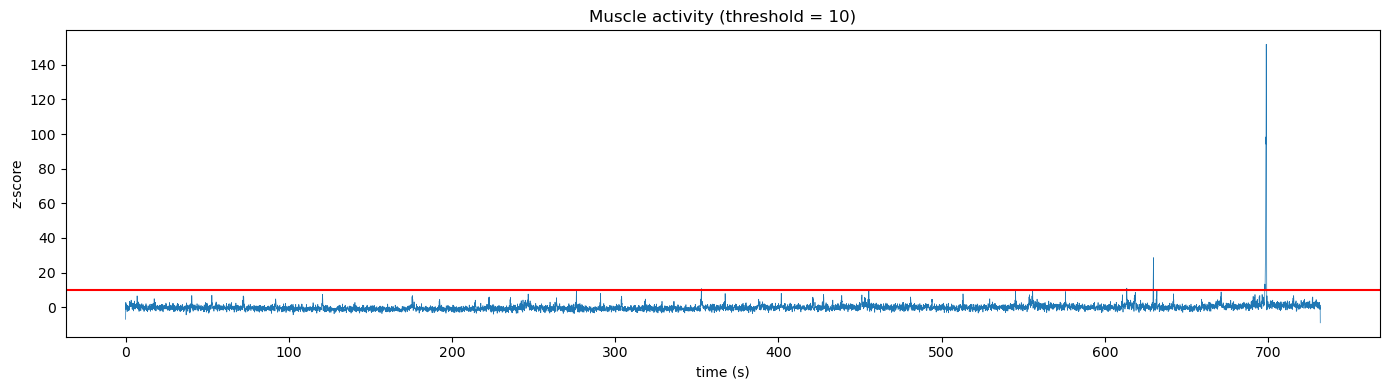

In [9]:
%matplotlib inline
fig1, ax = plt.subplots(figsize=(14, 4))
ax.plot(raw1.times, scores_muscle, linewidth=0.5)
ax.axhline(y=threshold_muscle, color='r')
ax.set(
    xlabel='time (s)',
    ylabel='z-score',
    title=f'Muscle activity (threshold = {threshold_muscle})',
)
fig1.tight_layout()

**Question 3:** What do we expect from the muscle z-score plot?

**Answer:** The threshold should be above the typical baseline level of the score and should catch clear high-frequency bursts. If the threshold is too low, large parts of the recording will be marked as muscle artefact. If it is too high, obvious high-frequency bursts will remain unannotated.

## Include annotations in the dataset and inspect

Now combine all annotations in the data. Calling `set_annotations()` replaces the current annotations in the Raw object. To preserve existing annotations, we first keep the annotations already present in the file and then add the manually reviewed blink/eye-movement annotations and the automatically detected muscle annotations.


In [10]:
annotations_event = raw1.annotations
annotations_manual_eye = load_manual_eye_annotations(
    first_file,
    raw1,
    allow_missing=skip_manual_eye_ann,
)
raw1.set_annotations(
    annotations_event + annotations_manual_eye + annotations_muscle
)

print(raw1.annotations)


Loaded 4 manual eye annotations from /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/manual_eye/sub-01_ses-01_task-IceSkating_run-01_desc-manualeye-annot.fif
<Annotations | 10 segments: BAD_blink (4), BAD_muscle (6)>


Inspect the annotations in the raw data browser.

In [18]:
%matplotlib qt
raw1.plot(start=50, block=True)


qt.pointer.dispatch: skipping QEventPoint(id=0 ts=0 pos=0,0 scn=766.273,442.332 gbl=766.273,442.332 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-766.273,-442.332 last=-766.273,-442.332 Δ 766.273,442.332) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=693.374,429.013 gbl=693.374,429.013 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-693.374,-429.013 last=-693.374,-429.013 Δ 693.374,429.013) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=297.942,526.066 gbl=297.942,526.066 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-297.942,-526.066 last=-297.942,-526.066 Δ 297.942,526.066) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=-0.845367,630.309 gbl=-0.845367,630.309 Released ellipse=(1x1 ∡ 0) vel=0,0 press=0.845367,-630.309 last=0.845367,-630.309 Δ -0.845367,630.309) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=386.961,558.217 gbl=386.961,558.217 Released ellip

Channels marked as bad:
none


<mne_qt_browser._pg_figure.MNEQtBrowser(0x0) at 0x1850246c0>

To specifically inspect the eye-tracker analog channels, display the configured MISC channels.

In [14]:
%matplotlib qt

scl = dict(misc=1.0)
eye_picks = mne.pick_channels(raw1.ch_names, include=eye_tracker_channels)
raw1.plot(picks=eye_picks, scalings=scl, start=50, block=True)


qt.pointer.dispatch: skipping QEventPoint(id=0 ts=0 pos=0,0 scn=506.029,317.586 gbl=506.029,317.586 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-506.029,-317.586 last=-506.029,-317.586 Δ 506.029,317.586) : no target window
qt.pointer.dispatch: skipping QEventPoint(id=1 ts=0 pos=0,0 scn=621.232,244.685 gbl=621.232,244.685 Released ellipse=(1x1 ∡ 0) vel=0,0 press=-621.232,-244.685 last=-621.232,-244.685 Δ 621.232,244.685) : no target window
2026-07-20 13:22:13.314 python[1574:3718036] _TIPropertyValueIsValid called with 4 on nil context!
2026-07-20 13:22:13.314 python[1574:3718036] imkxpc_getApplicationProperty:reply: called with incorrect property value 4, bailing.
2026-07-20 13:22:13.314 python[1574:3718036] Text input context does not respond to _valueForTIProperty:


: 

**Question 4:** Why are artefacts annotated rather than removed in this notebook?

**Answer:** Annotation preserves the raw time series and records where artefacts occur. Later steps can decide whether to reject epochs overlapping these annotations. This is more transparent than deleting data immediately, especially when exclusion criteria may change.

Save the annotated first run as a FIF file and save the annotations as a CSV file.

In [ ]:
raw1.save(annotation_files[first_file], overwrite=True)
raw1.annotations.save(annotation_csv_files[first_file], overwrite=True)
print('Saved', annotation_files[first_file])
print('Saved', annotation_csv_files[first_file])

Writing /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_desc-annotated_meg.fif
Closing /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_desc-annotated_meg.fif
[done]
Saved /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_desc-annotated_meg.fif
Saved /Users/goal0312/Desktop/thesis/data/derivatives/mne-preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-IceSkating_run-01_desc-annotations.csv


: 

## Perform artefact annotation on the rest of the dataset

Now apply the same finalisation step to the remaining MaxFiltered runs. Blink and eye-movement annotations are not detected here; they are loaded from the manual eye-annotation files saved above. Muscle artefacts are still annotated automatically with the same threshold used for the first-run example.

If `skip_manual_eye_ann = False`, the code stops when a run has no manual eye-annotation file. If `skip_manual_eye_ann = True`, the code prints a warning and continues without blink or eye-movement annotations for that run.


In [ ]:
def count_annotations_with_prefix(annotations, prefix):
    """Count annotations whose description starts with a given prefix."""
    return sum(description.startswith(prefix) for description in annotations.description)


def annotate_one_run(maxfilter_file):
    """Load one MaxFiltered run, add manual eye and muscle annotations, and save it."""
    raw = mne.io.read_raw_fif(maxfilter_file, preload=True, verbose=True)

    annotations_manual_eye = load_manual_eye_annotations(
        maxfilter_file,
        raw,
        allow_missing=skip_manual_eye_ann,
    )
    annotations_muscle, _ = annotate_muscle_zscore(
        raw,
        ch_type='mag',
        threshold=threshold_muscle,
        min_length_good=0.2,
        filter_freq=[110, 140],
    )

    raw.set_annotations(
        raw.annotations + annotations_manual_eye + annotations_muscle
    )
    raw.save(annotation_files[maxfilter_file], overwrite=True)
    raw.annotations.save(annotation_csv_files[maxfilter_file], overwrite=True)

    return {
        'input': str(maxfilter_file),
        'manual_eye_annotation_file': str(manual_eye_annotation_files[maxfilter_file]),
        'output_fif': str(annotation_files[maxfilter_file]),
        'output_csv': str(annotation_csv_files[maxfilter_file]),
        'n_blink_annotations': count_annotations_with_prefix(annotations_manual_eye, 'BAD_blink'),
        'n_eye_movement_annotations': count_annotations_with_prefix(
            annotations_manual_eye,
            'BAD_eye_movement',
        ),
        'n_muscle_annotations': len(annotations_muscle),
    }

run_summaries = []
for maxfilter_file in maxfilter_files[1:]:
    print(f'\nAnnotating {maxfilter_file.name}')
    run_summaries.append(annotate_one_run(maxfilter_file))

run_summaries


## Preregistration and publication

Preregistration: report the types of artefacts being annotated, the eye-tracker channels inspected for manual blink and eye-movement marking, and the muscle threshold selection.

Publication example:

"Artefacts were annotated in the MaxFiltered raw data and used later for trial rejection where relevant. Eye blinks and eye movements were manually identified by inspecting frontal MEG sensors together with analog eye-tracker signals stored in the FIF file as MISC channels. `MISC001`-`MISC003` represented left-eye analog signals and `MISC004`-`MISC006` represented right-eye analog signals. Muscle artefacts were identified from magnetometer data filtered in the 110-140 Hz range using a z-score threshold of 10. Artefact intervals were stored as MNE annotations and the raw data were not cropped or concatenated during this step."


## References

Muthukumaraswamy, S. (2013). High-frequency brain activity and muscle artifacts in MEG/EEG: a review and recommendations. *Frontiers in Human Neuroscience*, 7:138.

Hu Y, Yin C, Zhang J, Wang Y. (2018). Partial Least Square Aided Beamforming Algorithm in Magnetoencephalography Source Imaging. *Frontiers in Neuroscience*, 12:616.